In [18]:
import pandas as pd
import os

# Find the correct path automatically
home = os.path.expanduser("~")
DATASET_DIR = os.path.join(home, "cyb-project", "dataset")

# Confirm it works
print("Looking in:", DATASET_DIR)
print("Files found:", os.listdir(DATASET_DIR))

Looking in: /home/rajan/cyb-project/dataset
Files found: ['CEAS_08.csv', 'archive.zip', 'archive(1).zip', '20021010_easy_ham.tar.bz2', 'cww.csv', 'Enron.csv', 'Ling.csv', 'Nazario.csv', 'Nigerian_Fraud.csv', 'SpamAssasin.csv', 'phishing_email.csv', 'fradulent_emails.txt', 'easy_ham', 'check_cvs.sh']


In [19]:
# Load all key CSVs
df_ceas     = pd.read_csv(f"{DATASET_DIR}/CEAS_08.csv")
df_enron    = pd.read_csv(f"{DATASET_DIR}/Enron.csv")
df_nazario  = pd.read_csv(f"{DATASET_DIR}/Nazario.csv")
df_phishing = pd.read_csv(f"{DATASET_DIR}/phishing_email.csv")
df_spamass  = pd.read_csv(f"{DATASET_DIR}/SpamAssasin.csv")

datasets = {
    "CEAS_08":    df_ceas,
    "Enron":      df_enron,
    "Nazario":    df_nazario,
    "phishing":   df_phishing,
    "SpamAssasin":df_spamass,
}

for name, df in datasets.items():
    print(f"=== {name} ===")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    if 'label' in df.columns:
        print(f"  Labels: {df['label'].value_counts().to_dict()}")
    print()

=== CEAS_08 ===
  Shape: (39154, 7)
  Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
  Labels: {1: 21842, 0: 17312}

=== Enron ===
  Shape: (29767, 3)
  Columns: ['subject', 'body', 'label']
  Labels: {0: 15791, 1: 13976}

=== Nazario ===
  Shape: (1565, 7)
  Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
  Labels: {1: 1565}

=== phishing ===
  Shape: (82486, 2)
  Columns: ['text_combined', 'label']
  Labels: {1: 42891, 0: 39595}

=== SpamAssasin ===
  Shape: (5809, 7)
  Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
  Labels: {0: 4091, 1: 1718}



In [20]:
# Check nulls in each dataset
for name, df in datasets.items():
    print(f"=== {name} ===")
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(nulls if not nulls.empty else "  No nulls ✅")
    print()

=== CEAS_08 ===
receiver    462
subject      28
dtype: int64

=== Enron ===
subject    198
dtype: int64

=== Nazario ===
receiver    96
date         1
subject      4
dtype: int64

=== phishing ===
  No nulls ✅

=== SpamAssasin ===
receiver    210
subject      16
body          1
dtype: int64



In [21]:
# Look at one real phishing email vs one ham email
print("=== PHISHING SAMPLE (label=1) ===")
sample = df_phishing[df_phishing['label'] == 1].iloc[0]['text_combined']
print(sample[:500])

print("\n=== HAM SAMPLE (label=0) ===")
sample = df_phishing[df_phishing['label'] == 0].iloc[0]['text_combined']
print(sample[:500])

=== PHISHING SAMPLE (label=1) ===
link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter featuring latest ieee 802 11 g wireless technology deliverincredibly fast data transfer 2 4 ghz freq

=== HAM SAMPLE (label=0) ===
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls


In [22]:
# Standardize all datasets to just: subject, body, label
# Then merge into one master dataframe

def standardize(df, subject_col=None, body_col=None, label_col='label'):
    out = pd.DataFrame()
    out['subject'] = df[subject_col].fillna('') if subject_col else ''
    out['body']    = df[body_col].fillna('') if body_col else ''
    out['label']   = df[label_col]
    return out

df1 = standardize(df_ceas,     subject_col='subject', body_col='body')
df2 = standardize(df_enron,    subject_col='subject', body_col='body')
df3 = standardize(df_nazario,  subject_col='subject', body_col='body')
df4 = standardize(df_spamass,  subject_col='subject', body_col='body')

# phishing_email.csv has combined text — split into body, leave subject empty
df5 = standardize(df_phishing, body_col='text_combined')

# Merge all
master = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

# Combine subject + body into one text column
master['text'] = (master['subject'] + ' ' + master['body']).str.strip()

# Drop rows where text is empty
master = master[master['text'].str.len() > 10].reset_index(drop=True)

print("Master dataset shape:", master.shape)
print("\nLabel distribution:")
print(master['label'].value_counts())
print(f"\nPhishing %: {master['label'].mean()*100:.1f}%")

Master dataset shape: (76291, 4)

Label distribution:
label
1    39097
0    37194
Name: count, dtype: int64

Phishing %: 51.2%


In [23]:
# Remove duplicates
before = len(master)
master = master.drop_duplicates(subset='text').reset_index(drop=True)
after = len(master)

print(f"Removed {before - after} duplicates")
print(f"Final dataset size: {after} rows")
print(f"\nFinal label split:")
print(master['label'].value_counts())

Removed 32 duplicates
Final dataset size: 76259 rows

Final label split:
label
1    39065
0    37194
Name: count, dtype: int64


In [24]:
# Save master dataset to backend/data/
import os

SAVE_DIR = os.path.join(os.path.expanduser("~"), 
                        "cyb-project", "email_sys", "backend", "data")

save_path = os.path.join(SAVE_DIR, "master_dataset.csv")

master[['text', 'label']].to_csv(save_path, index=False)

print(f"✅ Saved to: {save_path}")
print(f"   Rows: {len(master)}")
print(f"   Size: {os.path.getsize(save_path)/1024/1024:.1f} MB")

✅ Saved to: /home/rajan/cyb-project/email_sys/backend/data/master_dataset.csv
   Rows: 76259
   Size: 124.6 MB


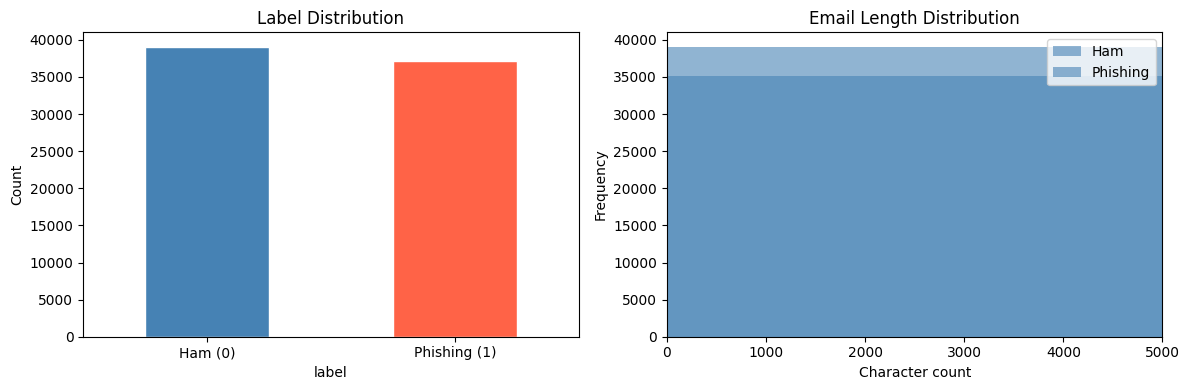


Avg phishing email length: 1291 chars
Avg ham email length:      2138 chars


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Label distribution
master['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
axes[0].set_title('Label Distribution')
axes[0].set_xticklabels(['Ham (0)', 'Phishing (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Plot 2: Email text length distribution
master['text_len'] = master['text'].str.len()
master.groupby('label')['text_len'].plot(
    kind='hist', ax=axes[1],
    bins=50, alpha=0.6,
    color=['steelblue', 'tomato'],
    legend=True
)
axes[1].set_title('Email Length Distribution')
axes[1].set_xlabel('Character count')
axes[1].legend(['Ham', 'Phishing'])
axes[1].set_xlim(0, 5000)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dataset_overview.png'), dpi=150)
plt.show()

print(f"\nAvg phishing email length: {master[master['label']==1]['text_len'].mean():.0f} chars")
print(f"Avg ham email length:      {master[master['label']==0]['text_len'].mean():.0f} chars")